In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [6]:
df =  pd.read_csv('Sample - Superstore.csv',encoding='latin1')

In [7]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [10]:
df['Order Date'] = pd.to_datetime(df["Order Date"])

In [12]:
df["Month"] = df["Order Date"].dt.to_period("M")

In [13]:
monthly_sales = df.groupby("Month")["Sales"].sum()

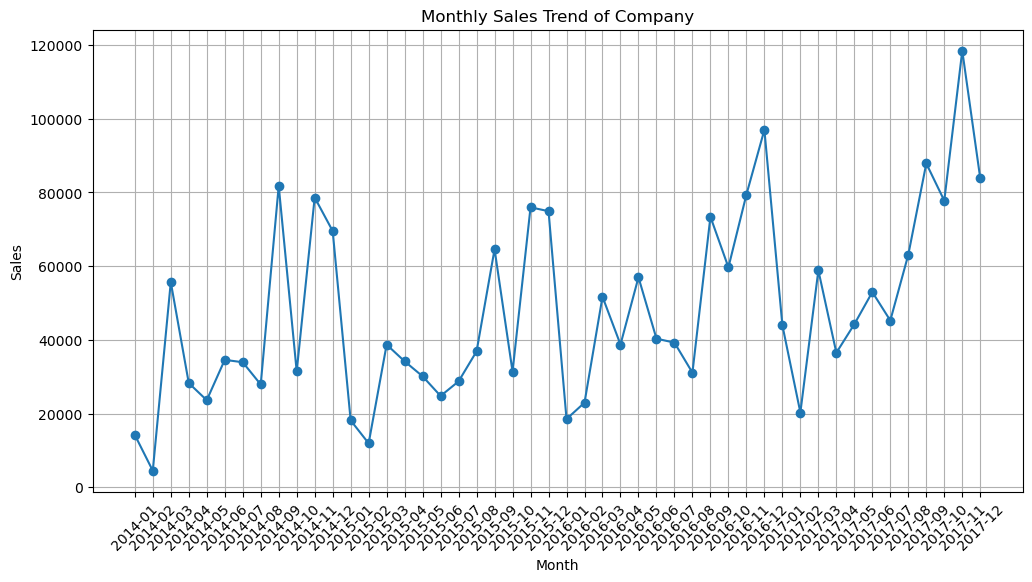

In [18]:
plt.figure(figsize=(12,6))

plt.plot(
    monthly_sales.index.astype(str),
    monthly_sales.values,
    marker='o'
)
plt.title("Monthly Sales Trend of Company")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.grid(True)
plt.xticks(rotation=45)
plt.show()

In [19]:
print(df["Category"].unique())
print(df["Sub-Category"].unique())

['Furniture' 'Office Supplies' 'Technology']
['Bookcases' 'Chairs' 'Labels' 'Tables' 'Storage' 'Furnishings' 'Art'
 'Phones' 'Binders' 'Appliances' 'Paper' 'Accessories' 'Envelopes'
 'Fasteners' 'Supplies' 'Machines' 'Copiers']


In [27]:
Furniture = df[df["Category"] == "Furniture"].copy()
Technology = df[df["Category"] == "Technology"].copy()

In [28]:
Furniture["Month"] = Furniture["Order Date"].dt.to_period("M")
Technology["Month"] = Technology["Order Date"].dt.to_period("M")

In [32]:
Furniture_sales = Furniture.groupby("Month")["Sales"].sum()
Technology_sales = machines.groupby("Month")["Sales"].sum()

In [33]:
print(Furniture_sales.head())
print(Technology_sales.head())

Month
2014-01     6242.525
2014-02     1839.658
2014-03    14573.956
2014-04     7944.837
2014-05     6912.787
Freq: M, Name: Sales, dtype: float64
Month
2014-03    25314.658
2014-04      287.968
2014-06      691.761
2014-09    22420.282
2014-10      101.994
Freq: M, Name: Sales, dtype: float64


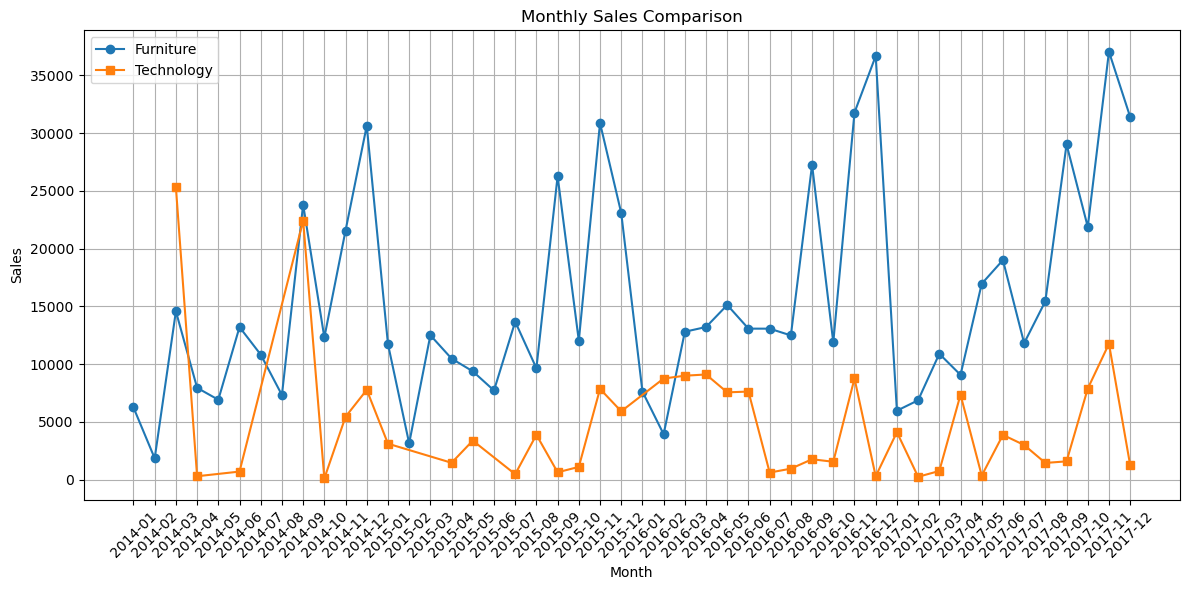

In [34]:
plt.figure(figsize=(12,6))

plt.plot(
    Furniture_sales.index.astype(str),
    Furniture_sales.values,
    marker='o',
    label="Furniture"
)

plt.plot(
    Technology_sales.index.astype(str),
    Technology_sales.values,
    marker='s',
    label="Technology"
)

plt.title("Monthly Sales Comparison")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()